# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks XI

<br/>
Jiří Fejlek

2026-05-31
<br/>

The EfficientNets [[1](#1), [2](#2)] are the next convolutional neural networks we will introduce in these small projects. In terms of architecture, these CNNs are a continuation of MobileNet V3 [[3](#3)], yielding small, efficient, and accurate models.


## Table of Contents

- [EfficientNet](#efficientnet)
    - [Transfer Learning EfficientNet-b0 from ImageNet to CIFAR-10](#transfer)
- [EfficientNet V2](#efficientnet2)
- [References](#references)

## EfficientNet <a class="anchor" id="efficientnet"></a>

Let us start with the original EfficientNet [[1](#1)]. As usual, we will repeat the common functions we use in our implementations.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
from torchvision.ops import StochasticDepth

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

The original EfficientNet [[1](#1)] is essentially a repeat of MobileNet V3 [[3](#3)]. The main contribution of the paper that introduced EfficientNet was a new *compound* scaling scheme that scales up the width, depth, and input resolution of the model. Here, we will implement the baseline model *EfficientNet b0* [[1](#1)], which has the following architecture.

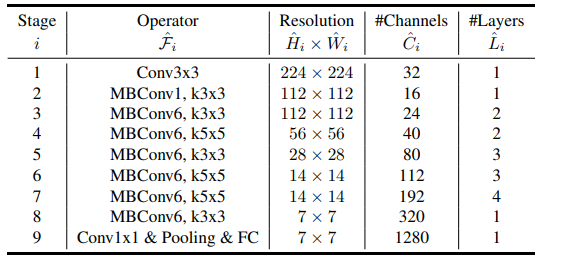

MBConv convolution blocks are as follows [[2](#2)].

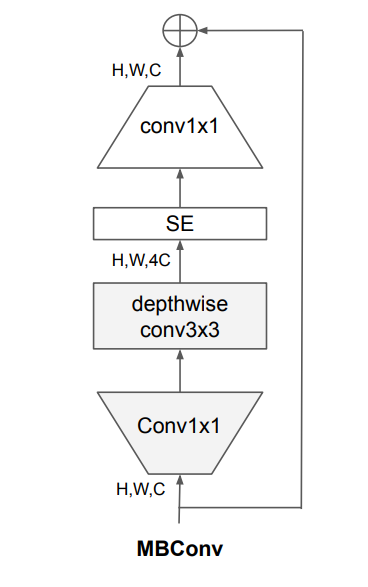

We observe that the MBConv blocks are the same as the block in MobileNet V3 [[3](#3)] (those with squeeze-and-excitation). Hence, we will reuse our implementation from the previous small project.

In [6]:
class Depthwise_convolution(nn.Module):

    def __init__(self, num_channels, kernel_size, padding, stride):
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.LazyConv2d(num_channels, kernel_size = kernel_size, stride = stride, padding = padding, groups = num_channels), 
        )
            
    def forward(self, x):
        output = self.net_stack(x)
        return output

In [7]:
class MBConv_block(nn.Module):
    
    def __init__(self, channels_in, channels_out, expansion_ratio, kernel_size, stride, padding, stochastic_depth_prob = 0): # in_channels == out_channels and stride = 1 for an inverted residual block!
        super().__init__()

        self.channels_in = channels_in
        self.channels_out = channels_out
        self.stride = stride

        
        if expansion_ratio>1:
            self.net_stack = nn.Sequential(
            nn.Conv2d(channels_in, channels_in*expansion_ratio, kernel_size=1),  nn.LazyBatchNorm2d(), nn.SiLU(),
            Depthwise_convolution(channels_in*expansion_ratio, kernel_size = kernel_size, stride = stride, padding = padding),  nn.LazyBatchNorm2d(), nn.SiLU(),
            torchvision.ops.SqueezeExcitation(input_channels = channels_in*expansion_ratio, squeeze_channels = channels_in//4, activation = nn.SiLU, scale_activation=nn.Sigmoid),
            nn.LazyConv2d(channels_out, kernel_size=1), nn.LazyBatchNorm2d()
            )

            self.stochastic_depth = StochasticDepth(stochastic_depth_prob, "row")    
        else:
            self.net_stack = nn.Sequential(
            Depthwise_convolution(channels_in, kernel_size = kernel_size, stride = stride, padding = padding), nn.LazyBatchNorm2d(), nn.SiLU(),
            torchvision.ops.SqueezeExcitation(input_channels = channels_in, squeeze_channels = channels_in//4, activation = nn.SiLU, scale_activation=nn.Sigmoid),
            nn.LazyConv2d(channels_out, kernel_size=1), nn.LazyBatchNorm2d()
            )
                

            self.stochastic_depth = StochasticDepth(stochastic_depth_prob, "row")

    def forward(self, x):
        if self.channels_in == self.channels_out and self.stride == 1:
            y = self.net_stack(x)
            return self.stochastic_depth(y) + x
        else:
            y = self.net_stack(x)
            return y

We based the details of our implementation of EfficientNet on the one from https://docs.pytorch.org/vision/main/models/efficientnet.html.

In [8]:
class EfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         
        self.net_stack = nn.Sequential(
            
            nn.LazyConv2d(32, kernel_size=3, stride=2, padding=1),  nn.LazyBatchNorm2d(), nn.SiLU(), 
            MBConv_block(32, 16, expansion_ratio = 1, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
           
            MBConv_block(16, 24, expansion_ratio = 6, kernel_size = 3, stride = 2, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(24, 24, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            
            MBConv_block(24, 40, expansion_ratio = 6, kernel_size = 5, stride = 2, padding = 2, stochastic_depth_prob = 0.2),
            MBConv_block(40, 40, expansion_ratio = 6, kernel_size = 5, stride = 1, padding = 2, stochastic_depth_prob = 0.2),

            
            MBConv_block(40, 80, expansion_ratio = 6, kernel_size = 3, stride = 2, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(80, 80, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(80, 80, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            
            MBConv_block(80, 112, expansion_ratio = 6, kernel_size = 5, stride = 2, padding = 2, stochastic_depth_prob = 0.2),
            MBConv_block(112, 112, expansion_ratio = 6, kernel_size = 5, stride = 1, padding = 2, stochastic_depth_prob = 0.2),
            MBConv_block(112, 112, expansion_ratio = 6, kernel_size = 5, stride = 1, padding = 2, stochastic_depth_prob = 0.2),
            
            MBConv_block(112, 192, expansion_ratio = 6, kernel_size = 5, stride = 1, padding = 2, stochastic_depth_prob = 0.2),
            MBConv_block(192, 192, expansion_ratio = 6, kernel_size = 5, stride = 1, padding = 2, stochastic_depth_prob = 0.2),
            MBConv_block(192, 192, expansion_ratio = 6, kernel_size = 5, stride = 1, padding = 2, stochastic_depth_prob = 0.2),
            MBConv_block(192, 192, expansion_ratio = 6, kernel_size = 5, stride = 1, padding = 2, stochastic_depth_prob = 0.2),

            MBConv_block(192, 320, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
                
            nn.LazyConv2d(1280, kernel_size=1),  nn.LazyBatchNorm2d(), nn.SiLU(),
            nn.AdaptiveAvgPool2d((1,1)), 
            nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [9]:
layer_summary(EfficientNet(10),(10, 1, 128, 128))

Conv2d output shape:	 torch.Size([10, 32, 64, 64])
BatchNorm2d output shape:	 torch.Size([10, 32, 64, 64])
SiLU output shape:	 torch.Size([10, 32, 64, 64])
MBConv_block output shape:	 torch.Size([10, 16, 64, 64])
MBConv_block output shape:	 torch.Size([10, 24, 32, 32])
MBConv_block output shape:	 torch.Size([10, 24, 32, 32])
MBConv_block output shape:	 torch.Size([10, 40, 16, 16])
MBConv_block output shape:	 torch.Size([10, 40, 16, 16])
MBConv_block output shape:	 torch.Size([10, 80, 8, 8])
MBConv_block output shape:	 torch.Size([10, 80, 8, 8])
MBConv_block output shape:	 torch.Size([10, 80, 8, 8])
MBConv_block output shape:	 torch.Size([10, 112, 4, 4])
MBConv_block output shape:	 torch.Size([10, 112, 4, 4])
MBConv_block output shape:	 torch.Size([10, 112, 4, 4])
MBConv_block output shape:	 torch.Size([10, 192, 4, 4])
MBConv_block output shape:	 torch.Size([10, 192, 4, 4])
MBConv_block output shape:	 torch.Size([10, 192, 4, 4])
MBConv_block output shape:	 torch.Size([10, 192, 4, 4])
MB

Let us try the model. We start with the Fashion-MNIST dataset [[5](#5)]. 

In [10]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.RandomResizedCrop(size = [128, 128], scale = [0.9,1.1]),
        torchvision.transforms.Normalize(0.5, 0.5),
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Resize([128, 128]),
        torchvision.transforms.Normalize(0.5, 0.5)
    ]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# mobilenet initialization
EfficientNet_cuda = EfficientNet(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
EfficientNet_cuda(x);
EfficientNet_cuda.apply(init_weights_he);

In [11]:
sum(p.numel() for p in EfficientNet_cuda.parameters() if p.requires_grad)

4040790

In [12]:
optim_SGD_cuda =  torch.optim.SGD(EfficientNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, EfficientNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2182.4350533485413


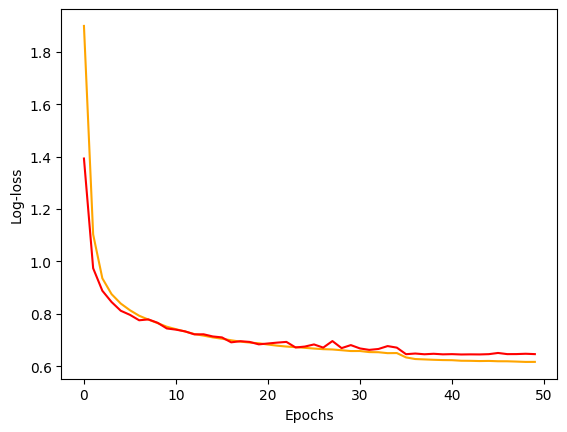

In [13]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

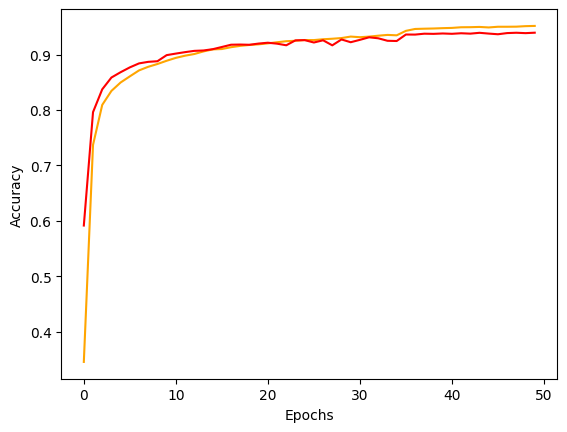

In [14]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

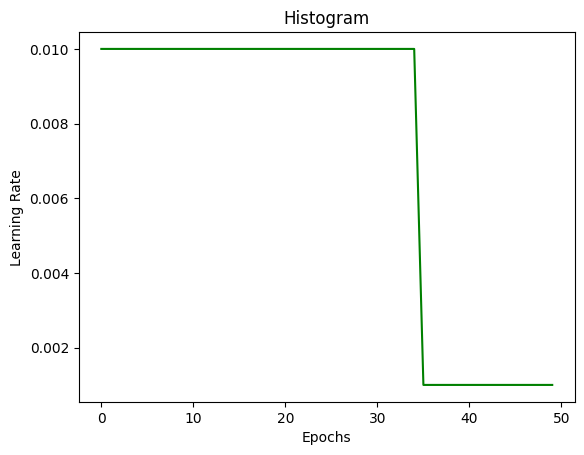

In [15]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [16]:
accu_epochs_train[49]

0.9516333341598511

In [17]:
accu_epochs_test[49]

0.9393999576568604

In [18]:
accu_epochs_test.max()

0.9393999576568604

This is pretty reasonable performance. Let us continue with the CIFAR-10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html).

In [19]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.RandomResizedCrop(size=[128,128], scale = [0.8, 1.4]),
        torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Resize([128, 128]),
        torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])
    ]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

# mobilenet initialization
EfficientNet_cuda = EfficientNet(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
EfficientNet_cuda(x);
EfficientNet_cuda.apply(init_weights_he);

In [20]:
optim_SGD_cuda =  torch.optim.SGD(EfficientNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[75], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, EfficientNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

6527.023765325546


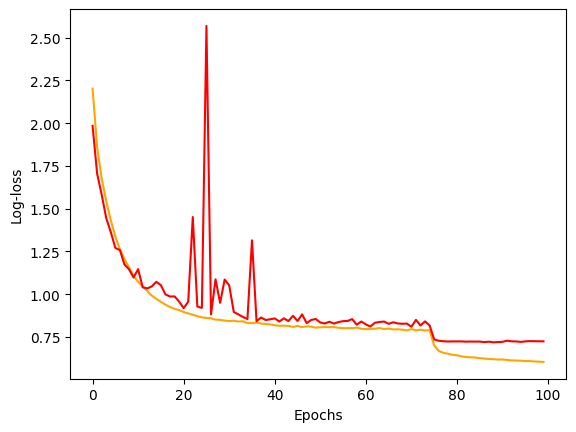

In [21]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

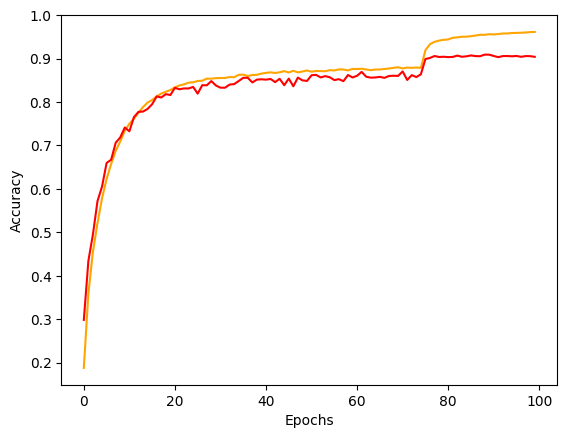

In [22]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

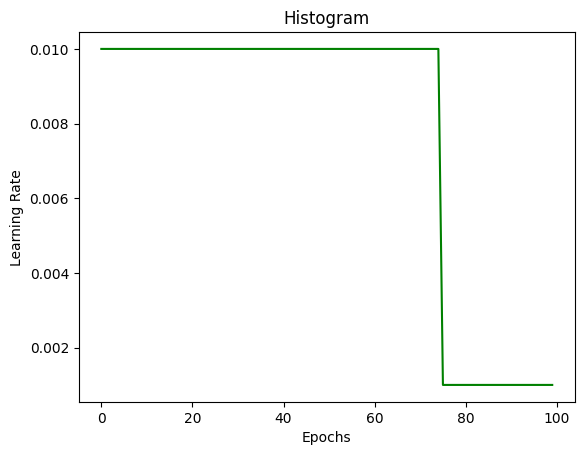

In [23]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [24]:
accu_epochs_train[99]

0.9614199995994568

In [25]:
accu_epochs_test[99]

0.9041000008583069

In [26]:
accu_epochs_test.max()

0.9090999960899353

Similar to our previous experience with MobileNet V3, the performance is not that great. However, as we teased at the end of the previous project, we have entered an era of machine learning in which *transfer learning* has become widely adopted.

### Transfer Learning EfficientNet-b0 from ImageNet to CIFAR-10 <a class="anchor" id="transfer"></a>

Our standard approach in our past projects was to train a model on a given dataset *from scratch*. The main issue with this approach is that the model we train can be severely limited by the dataset's size (e.g., CIFAR-10 has merely 60,000 images). However, let us suppose that we have trained a model on a large dataset (say, ImageNet-1k, with 1.3 million images). It is reasonable to expect that a model trained on ImageNet-1k and performing well should also perform well on CIFAR-10 after some small tweaks, such as recreating the final classification layer (since the categories in ImageNet-1k differ from those in CIFAR-10). Both of these tasks are about image classification, after all, and hence the model that performs well on one dataset should perform well on the other. This intuition is, by and large, correct; specifically, the models that perform well on ImageNet-1k also perform well on other image-related problems [[6](#6)], demonstrating that their ability to classify images on ImageNet-1k *transfers* to other tasks.  

Now, the most common way to technically transfer a model from one task to another is *fine-tuning*. During fine-tuning, we retrain (often just parts of) the model pretrained for the previous task for a new task. 

Let us download the EfficientNet-b0 model from https://docs.pytorch.org/vision/main/models/efficientnet.html that was trained on ImageNet-1k. 

In [27]:
EfficientNet_cuda = torchvision.models.efficientnet_b0(weights='IMAGENET1K_V1')

Our task is to transfer this model to CIFAR-10. We could fine-tune all model parameters (typically by training the model with a small learning rate). However, we will exploit the specific structure of the CNNs and retrain merely the batch normalization layers (and the classification layer) [[7](#7)]. Let us remind ourselves that batch normalization is given as
$$ y = \gamma\frac{x - \mathrm{E}x}{\sqrt{\text{Var }x + \varepsilon}} +  \beta,$$
where $\beta$ and $\gamma$ are learnable the so-called *affine* parameters. Numerical experiments indicate that fine-tuning the affine parameters for the new dataset yields performance similar to fine-tuning all model parameters [[7](#7)].

Hence, we will first freeze all parameters by disabling the gradient computations.

In [28]:
for param in EfficientNet_cuda.parameters():
    param.requires_grad = False

Then, we will unfreeze the affine parameters of batch normalization layers.

In [29]:
for m in EfficientNet_cuda.modules():
    if isinstance(m, nn.BatchNorm2d):
        m.weight.requires_grad_(True)
        m.bias.requires_grad_(True)

We also have to alter the classification layer that computes probability logits from the extracted features.

In [30]:
EfficientNet_cuda.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

We replace it with a new layer that we must train from scratch.

In [31]:
EfficientNet_cuda.classifier = nn.Sequential(nn.Dropout(0.2),nn.Linear(1280,10))
EfficientNet_cuda = EfficientNet_cuda.to(cuda_device)

Since we are dealing with CNNs with batch normalization, there is one last detail to keep in mind. Looking back at the batch normalization formula, it entails $\mathrm{E}x$ and $\text{Var }x$. These are estimated from batches during training (they are not learned using gradients!) and remain fixed during inference. Since we are dealing with a much smaller dataset and we will be using much smaller batches, it is recommended to fix these estimates [[7](#7)]. We can do this in PyTorch by setting the batch normalization layers to *eval* mode during training. 

In [32]:
def fine_tune_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    # setting batch norm layers to eval mode
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            
    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

We are almost ready to fine-tune the EfficientNet model. We will mostly follow the setting from [[2](#2)]. Instead of standard image augmentation using random cropping, we will use the cutout image augmentation [[8](#8)], which masks the random parts of the image; the implementation is from https://github.com/hysts/pytorch_cutout.

In [33]:
def cutout(mask_size, p, cutout_inside, mask_color=(0, 0, 0)):
    mask_size_half = mask_size // 2
    offset = 1 if mask_size % 2 == 0 else 0

    def _cutout(image):
        image = np.asarray(image).copy()

        if np.random.random() > p:
            return image

        h, w = image.shape[:2]

        if cutout_inside:
            cxmin, cxmax = mask_size_half, w + offset - mask_size_half
            cymin, cymax = mask_size_half, h + offset - mask_size_half
        else:
            cxmin, cxmax = 0, w + offset
            cymin, cymax = 0, h + offset

        cx = np.random.randint(cxmin, cxmax)
        cy = np.random.randint(cymin, cymax)
        xmin = cx - mask_size_half
        ymin = cy - mask_size_half
        xmax = xmin + mask_size
        ymax = ymin + mask_size
        xmin = max(0, xmin)
        ymin = max(0, ymin)
        xmax = min(w, xmax)
        ymax = min(h, ymax)
        image[ymin:ymax, xmin:xmax] = mask_color
        return image

    return _cutout

In [34]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.RandomHorizontalFlip(),
     torchvision.transforms.Resize([224,224]),
     cutout(mask_size = 128, p = 1, cutout_inside = False),
    ]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)

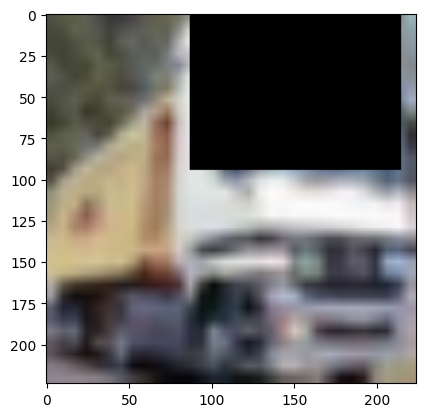

In [35]:
plt.imshow(cifar10_train[1][0]);

In [36]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.Resize([224,224]),
        cutout(mask_size = 128, p = 0.5, cutout_inside = False),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize([224,224]),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    ]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 50, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 50, shuffle = False)

We will also use the continuous cosine learning-rate decay rather than the piecewise-constant one. Other than that, the rest of the settings are pretty standard.

In [37]:
n_epochs = 50

optim_SGD_cuda =  torch.optim.SGD(EfficientNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.CosineAnnealingLR(optim_SGD_cuda, 50, eta_min = 0.00001)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = fine_tune_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, EfficientNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

4649.741956233978


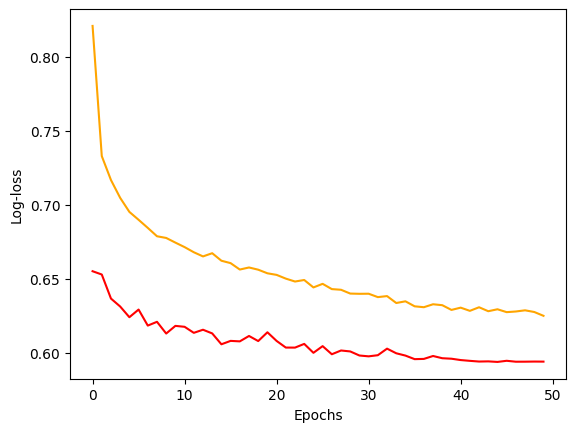

In [38]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

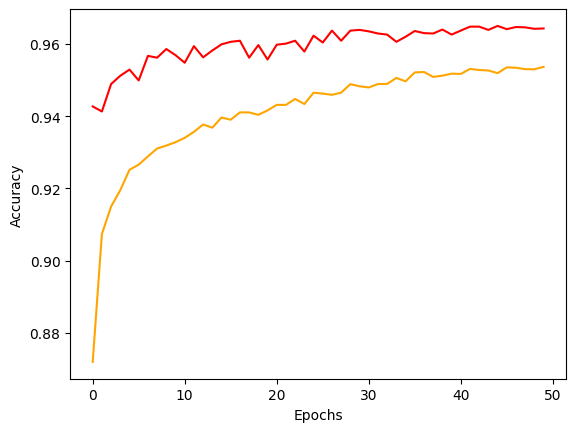

In [39]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

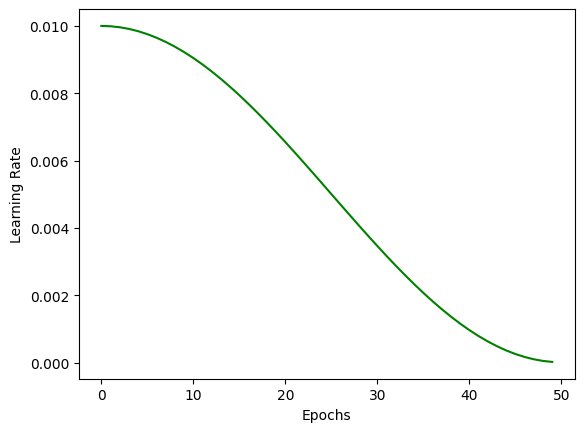

In [40]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [42]:
accu_epochs_train[49]

0.9536599516868591

In [43]:
accu_epochs_test[49]

0.9642999768257141

In [44]:
accu_epochs_test.max()

0.9649999737739563

We have attained a pretty respectable performance of almost 96.5%, which is our best result so far.

## EfficientNet V2 <a class="anchor" id="efficientnet2"></a>

EfficientNet V2 [[2](#2)] is a slight evolution of EfficientNet. The main change is the introduction of *fused* blocks in which depthwise separable convolutions are replaced by ordinary convolution.

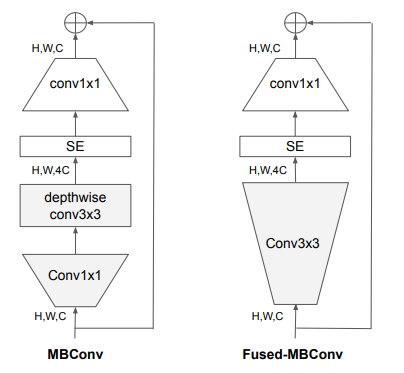

Now, not all depthwise separable convolutions are replaced (fused blocks use significantly more parameters and slow down training). However,  the authors of [[2](#2)] found a sweet spot: use fused blocks in the early stages and the usual MBConv block in the later stages. 

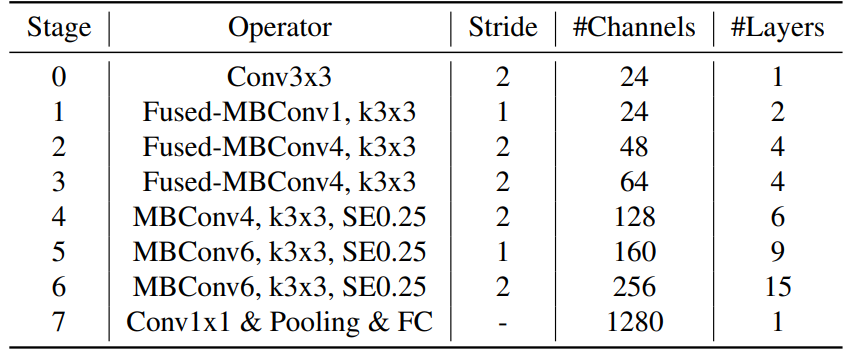

Let us implement the architecture.

In [45]:
class MBConv_block_fused(nn.Module):
    
    def __init__(self, channels_in, channels_out, expansion_ratio, kernel_size, stride, padding, stochastic_depth_prob = 0):
        super().__init__()

        self.channels_in = channels_in
        self.channels_out = channels_out
        self.stride = stride

        
        if expansion_ratio>1:
            
            self.net_stack = nn.Sequential(
                nn.Conv2d(channels_in, channels_in*expansion_ratio, kernel_size=3, padding = padding, stride = stride),  nn.LazyBatchNorm2d(), nn.SiLU(),
                nn.Conv2d(channels_in*expansion_ratio, channels_out, kernel_size=1), nn.LazyBatchNorm2d()
            )
  
        else:
            self.net_stack = nn.Sequential(
                nn.Conv2d(channels_in, channels_out, kernel_size=3, padding = padding, stride = stride),  nn.LazyBatchNorm2d(), nn.SiLU()
            )

        self.stochastic_depth = StochasticDepth(stochastic_depth_prob, "row")

    def forward(self, x):
        if self.channels_in == self.channels_out and self.stride == 1:
            y = self.net_stack(x)
            return self.stochastic_depth(y) + x
        else:
            y = self.net_stack(x)
            return y

In [46]:
class EfficientNetV2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         
        self.net_stack = nn.Sequential(
            
            nn.LazyConv2d(24, kernel_size=3, stride=2, padding=1),  nn.LazyBatchNorm2d(), nn.SiLU(), 
            
            MBConv_block_fused(24, 24, expansion_ratio = 1, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block_fused(24, 24, expansion_ratio = 1, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
               
            MBConv_block_fused(24, 48, expansion_ratio = 4, kernel_size = 3, stride = 2, padding = 1),
            MBConv_block_fused(48, 48, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block_fused(48, 48, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block_fused(48, 48, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),


            MBConv_block_fused(48, 64, expansion_ratio = 4, kernel_size = 3, stride = 2, padding = 1),
            MBConv_block_fused(64, 64, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block_fused(64, 64, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block_fused(64, 64, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),

            MBConv_block(64, 128, expansion_ratio = 4, kernel_size = 3, stride = 2, padding = 1),
            MBConv_block(128, 128, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(128, 128, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(128, 128, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(128, 128, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(128, 128, expansion_ratio = 4, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),


            MBConv_block(128, 160, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1),
            MBConv_block(160, 160, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(160, 160, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(160, 160, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(160, 160, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(160, 160, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(160, 160, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(160, 160, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(160, 160, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),

            MBConv_block(160, 256, expansion_ratio = 6, kernel_size = 3, stride = 2, padding = 1),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),
            MBConv_block(256, 256, expansion_ratio = 6, kernel_size = 3, stride = 1, padding = 1, stochastic_depth_prob = 0.2),

            nn.LazyConv2d(1280, kernel_size=1),  nn.LazyBatchNorm2d(), nn.SiLU(),
            nn.AdaptiveAvgPool2d((1,1)), 
            nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

We again plan to use transfer learning, but let us first train our model from scratch on Fashion-MNIST.

In [47]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.RandomResizedCrop(size = [128, 128], scale = [0.9,1.1]),
        torchvision.transforms.Normalize(0.5, 0.5),
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Resize([128, 128]),
        torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 125, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 125, shuffle = False)  


# mobilenet initialization
EfficientNet_cuda = EfficientNetV2(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
EfficientNet_cuda(x);
EfficientNet_cuda.apply(init_weights_he);

In [48]:
sum(p.numel() for p in EfficientNet_cuda.parameters() if p.requires_grad)

20266802

In [49]:
optim_SGD_cuda =  torch.optim.SGD(EfficientNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, EfficientNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3669.563644886017


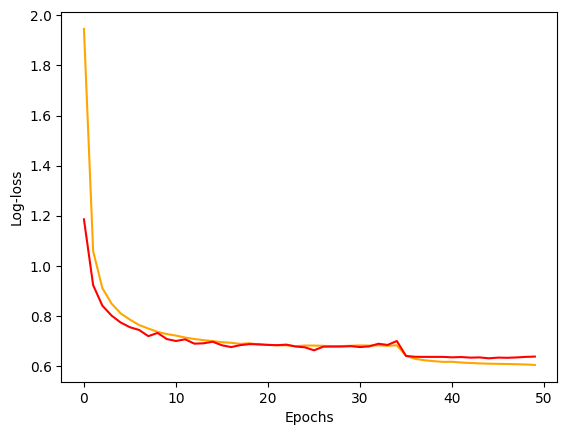

In [50]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

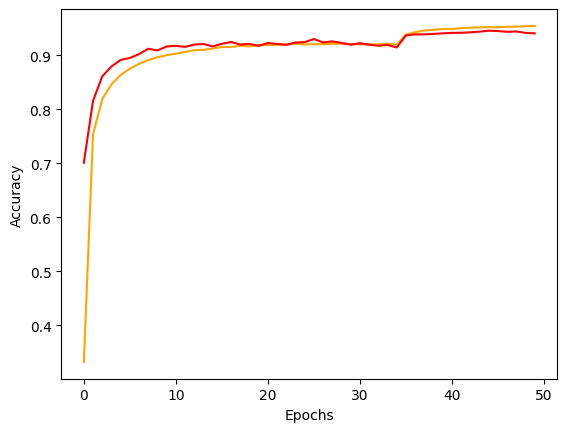

In [51]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

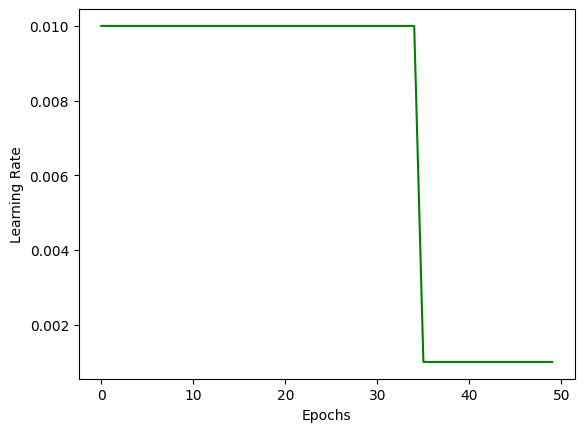

In [52]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [53]:
accu_epochs_train[49]

0.9544000029563904

In [54]:
accu_epochs_test[49]

0.9405999779701233

In [55]:
accu_epochs_test.max()

0.9455999732017517

We will use transfer learning on CIFAR-10 right away. Our model corresponds to *efficientnet_v2_s* from https://docs.pytorch.org/vision/main/models/efficientnetv2.html. 

In [56]:
EfficientNet_cuda = torchvision.models.efficientnet_v2_s(weights='IMAGENET1K_V1')

We will repeat the steps that we used when fine-tuning EfficientNet-b0.

In [57]:
for param in EfficientNet_cuda.parameters():
    param.requires_grad = False

In [58]:
for m in EfficientNet_cuda.modules():
    if isinstance(m, nn.BatchNorm2d):
        m.weight.requires_grad_(True)
        m.bias.requires_grad_(True)

In [59]:
EfficientNet_cuda.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [60]:
EfficientNet_cuda.classifier = nn.Sequential(nn.Dropout(0.2),nn.Linear(1280,10))
EfficientNet_cuda = EfficientNet_cuda.to(cuda_device)

In [61]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.Resize([224,224]),
        cutout(mask_size = 128, p = 0.5, cutout_inside = False),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize([224,224]),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    ]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 50, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 50, shuffle = False)

In [62]:
n_epochs = 50

optim_SGD_cuda =  torch.optim.SGD(EfficientNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.CosineAnnealingLR(optim_SGD_cuda, 50, eta_min = 0.00001)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = fine_tune_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, EfficientNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

6717.393633365631


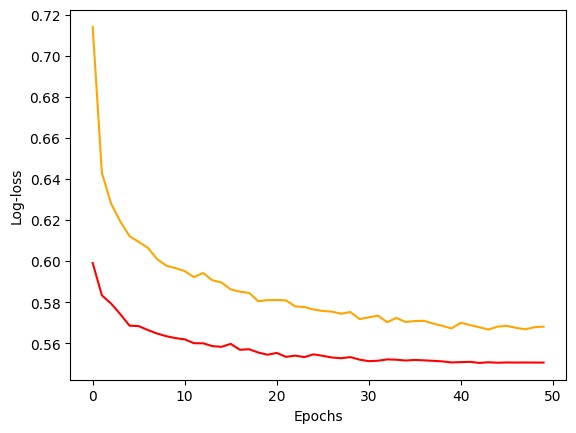

In [63]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

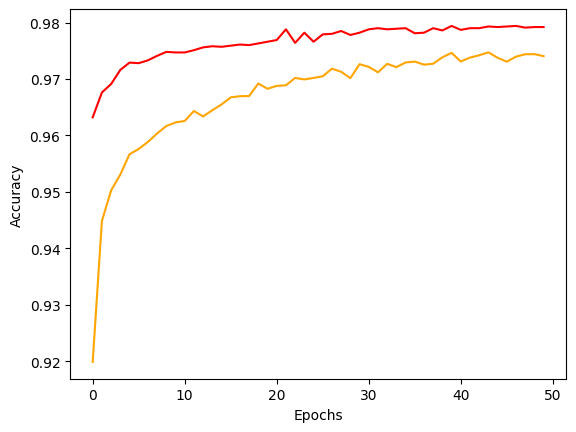

In [64]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

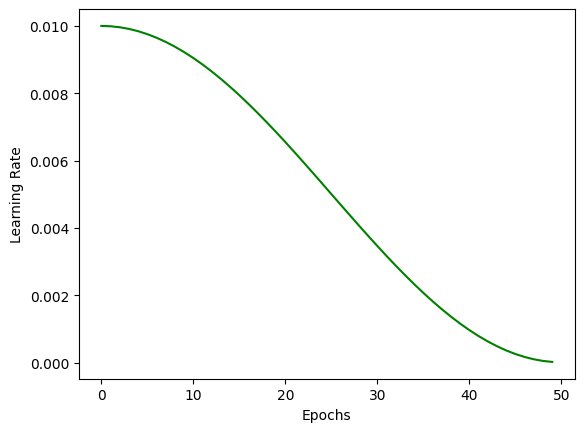

In [65]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [66]:
accu_epochs_train[49]

0.9740399718284607

In [67]:
accu_epochs_test[49]

0.9791999459266663

In [68]:
accu_epochs_test.max()

0.9793999791145325

We reached almost 98% accuracy on the test set. We should note that according to [[2](#2)] it is possible with *efficientnet_v2_l* exceed 99% accuracy!

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> TAN, Mingxing; LE, Quoc. EfficientNet: Rethinking model scaling for convolutional neural networks. In: *International conference on machine learning. PMLR, 2019.* p. 6105-6114.

<a id="2">[2]</a> TAN, Mingxing; LE, Quoc. EfficientNetv2: Smaller models and faster training. In: *International conference on machine learning. PMLR, 2021.* p. 10096-10106.

<a id="3">[3]</a> HOWARD, Andrew, et al. Searching for mobilenetv3. In: *Proceedings of the IEEE/CVF International conference on computer vision.* 2019. p. 1314-1324.

<a id="4">[4]</a> HU, Jie; SHEN, Li; SUN, Gang. Squeeze-and-excitation networks. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2018. p. 7132-7141.

<a id="5">[5]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-MNIST: a novel image dataset for benchmarking machine learning algorithms. *arXiv preprint arXiv:1708.07747*, 2017.

<a id="6">[6]</a> KORNBLITH, Simon; SHLENS, Jonathon; LE, Quoc V. Do better Imagenet models transfer better?. In: *Proceedings of the IEEE/CVF conference on computer vision and pattern recognition.* 2019. p. 2661-2671.

<a id="7">[7]</a> KANAVATI, Fahdi; TSUNEKI, Masayuki. Partial transfusion: on the expressive influence of trainable batch norm parameters for transfer learning. In: *Medical Imaging with Deep Learning. PMLR, 2021.* p. 338-353.

<a id="8">[8]</a> DEVRIES, Terrance; TAYLOR, Graham W. Improved regularization of convolutional neural networks with cutout. *arXiv preprint arXiv:1708.04552,* 2017.